In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline



In [24]:
from sklearn.datasets import load_breast_cancer

In [5]:
data = load_breast_cancer()

In [6]:
x = pd.DataFrame(data.data, columns = data.feature_names)
y = pd.Categorical.from_codes(data.target, data.target_names)

In [7]:
encoder = LabelEncoder()
encoded_y = pd.Series(encoder.fit_transform(y))

In [8]:
y

['malignant', 'malignant', 'malignant', 'malignant', 'malignant', ..., 'malignant', 'malignant', 'malignant', 'malignant', 'benign']
Length: 569
Categories (2, object): ['malignant', 'benign']

In [18]:
encoded_y.name = 'target'

In [19]:
encoded_y

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: target, Length: 569, dtype: int32

In [10]:
data.info()

AttributeError: info

In [11]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [12]:
x.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [17]:
encoded_y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 569 entries, 0 to 568
Series name: target
Non-Null Count  Dtype
--------------  -----
569 non-null    int32
dtypes: int32(1)
memory usage: 2.4 KB


In [21]:
data=pd.concat([x,encoded_y],axis=1)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

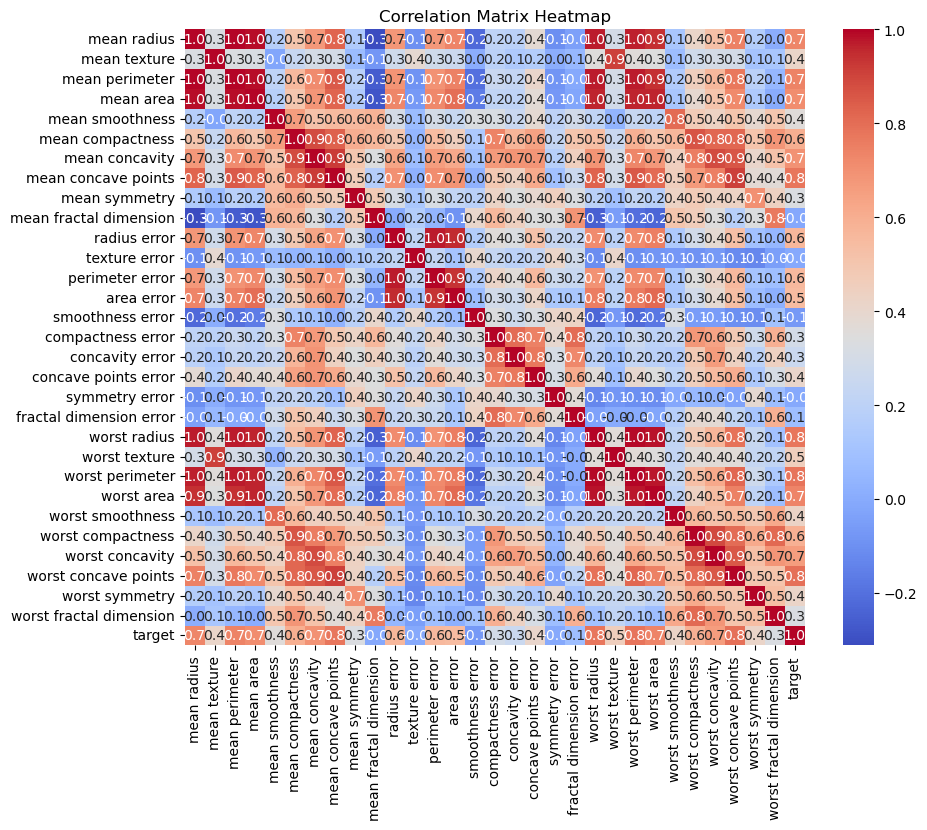

In [27]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm',fmt=".1f")
plt.title("Correlation Matrix Heatmap")
plt.show()

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [62]:
x_train,x_test,y_train,y_test= train_test_split(x,encoded_y,test_size=0.2,random_state=42)

In [63]:
x_train=scale.fit_transform(x_train)
x_test= scale.transform(x_test)

In [64]:
classifier_RF=RandomForestClassifier(n_estimators=100,criterion='entropy')
classifier_RF.fit(x_train,y_train)

RandomForestClassifier(criterion='entropy')

In [65]:
y_pred_RF=classifier_RF.predict(x_test)

In [66]:
classifier_DT=DecisionTreeClassifier(criterion = 'entropy', random_state = 42)
classifier_DT.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [67]:
y_pred_DT=classifier_DT.predict(x_test)

In [68]:
classifier_Ada= AdaBoostClassifier(DecisionTreeClassifier(max_depth=2), n_estimators=80,learning_rate=0.5)
classifier_Ada.fit(x_train,y_train)


E:\anaconda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2),
                   learning_rate=0.5, n_estimators=80)

In [69]:
y_pred_Ada=classifier_Ada.predict(x_test)

In [70]:
# Define meta-model

meta_model = LogisticRegression()

In [89]:
# Define base-models
base_models = [

('rf', RandomForestClassifier(n_estimators=100, random_state=42)),

('svm', SVC(kernel="rbf", random_state=42)),('knn',KNeighborsClassifier(n_neighbors=21) )

]

In [90]:
classifier_stack = StackingClassifier(estimators=base_models, final_estimator=meta_model,cv=5)
classifier_stack.fit(x_train,y_train)

StackingClassifier(cv=5,
                   estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('svm', SVC(random_state=42)),
                               ('knn', KNeighborsClassifier(n_neighbors=21))],
                   final_estimator=LogisticRegression())

In [91]:
y_pred_stack= classifier_stack.predict(x_test)

In [74]:
import xgboost as xgb

In [80]:
classifier_xgb = xgb.XGBClassifier(n_estimators=100, learning_rate=0.6, random_state=42)

classifier_xgb.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.6, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [81]:
y_pred_xgb= classifier_xgb.predict(x_test)

In [92]:
accuracy_DT=accuracy_score(y_test,y_pred_DT)
accuracy_RF=accuracy_score(y_test,y_pred_RF)
accuracy_Ada=accuracy_score(y_test,y_pred_Ada)
accuracy_stack=accuracy_score(y_test,y_pred_stack)
accuracy_xgb=accuracy_score(y_test,y_pred_xgb)



In [93]:
models = ["DecisionTree", "Random Forest", "AdaBoost", "Stacking", "XGBoost"]
accuracies = [accuracy_DT, accuracy_RF, accuracy_Ada, accuracy_stack, accuracy_xgb]

for model, acc in zip(models, accuracies):
    print(f"{model}: {acc:.2%}")

DecisionTree: 94.74%
Random Forest: 96.49%
AdaBoost: 96.49%
Stacking: 96.49%
XGBoost: 95.61%


In [ ]:
#confusion matrix

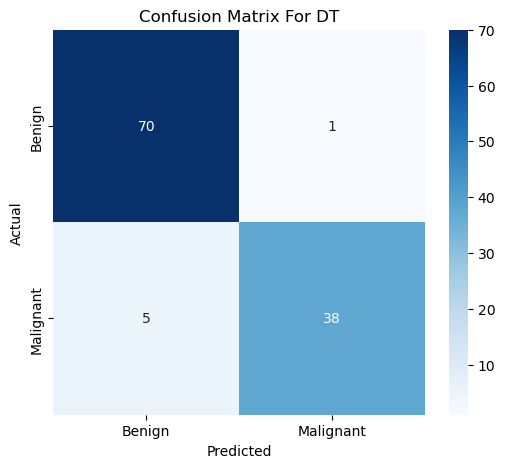

In [94]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_DT), annot=True, fmt='d',
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"], cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix For DT")
plt.show()

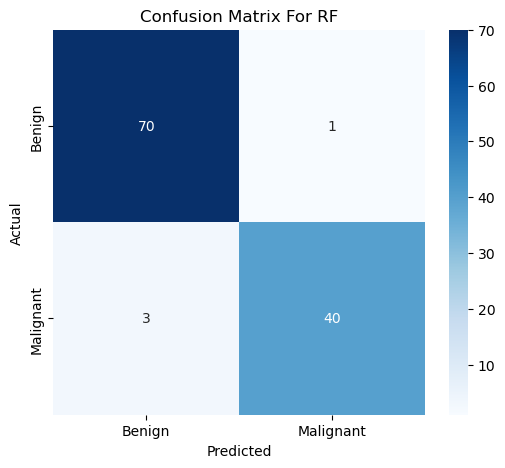

In [95]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_RF), annot=True, fmt='d',
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"], cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix For RF")
plt.show()

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_ada), annot=True, fmt='d',
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"], cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix For Ada")
plt.show()